<a href="https://colab.research.google.com/github/Adbhavna1369/seu-lstm/blob/main/SEU_LSTM_Baseline_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SEU Prediction — LSTM Baseline
## A Colab Walkthrough for PhD Research

**Project:** Predicting cosmic ray-induced Single Event Upset (SEU) rates in LEO satellite and UAV onboard electronics using a stacked LSTM neural network.

**Data sources (full pipeline):** NASA AE9/AP9 RADBELT · NOAA SWPC SEP events · GOES-16/18 proton & electron flux · CREME96 simulated SEU rates

**This notebook:** Self-contained demo using *synthetic data* — no HPC or real data download needed. Validates the full pipeline end-to-end on CPU in under 2 minutes.

---

### 1.1 What is a Single Event Upset (SEU)?

A **Single Event Upset** occurs when a high-energy cosmic ray or solar energetic particle (SEP) strikes a memory cell in a microelectronic device, depositing enough charge to flip a bit from 0→1 or 1→0.

- **Cause:** Galactic cosmic rays (GCRs) and solar proton events (SPEs)
- **Effect:** Soft errors in SRAM, DRAM, FPGAs — potentially mission-critical in autonomous systems
- **Rate:** Measured in upsets per bit per day, or counts per orbit (our regression target)

The SEU rate depends on:
1. The particle flux environment (GOES proton/electron channels)
2. The device's Linear Energy Transfer (LET) threshold
3. The orbital altitude and inclination (radiation belt exposure)

### 1.2 Why LSTM?

Particle flux is a **multivariate time series** — the SEU rate at time *t+Δ* depends on the history of flux measurements up to *t*. LSTMs are well-suited because:

- They learn long-range temporal dependencies (Hochreiter & Schmidhuber, 1997)
- They handle multivariate inputs naturally (proton channels + electron channels + SEP flag)
- They have precedent in solar energetic particle forecasting (Nedal et al., 2023; Yi et al., 2025)

### 1.3 Prediction target

We frame this as **regression**: predict the SEU rate (counts/orbit) at *t + horizon* given a window of flux observations ending at *t*.

- **Window size:** 24 × 5-min steps = 2-hour lookback
- **Horizon:** 6 × 5-min steps = 30-minute forecast


---
## 2. Synthetic Data Generation

### 2.1 Why synthetic data?

Real GOES data requires fetching from NOAA SWPC archives (handled by `data_acquisition.py`). For this notebook we generate statistically representative synthetic data to validate the pipeline.

### 2.2 What does real GOES proton flux look like?

- **Quiet periods:** Low, slowly varying flux (~0.1–10 pfu) — log-normally distributed
- **SEP events:** Sudden 2–4 order-of-magnitude spikes lasting hours to days
- **Electron flux:** Similar structure, different energy channels

This heavy-tailed distribution is why we use **log1p transform** before normalisation, and **Huber loss** during training.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

# ── Simulation parameters ──────────────────────────────────────────────────
N_TIMESTEPS  = 5000          # total 5-min steps (~17 days)
FREQ         = "5min"
START        = pd.Timestamp("2022-06-01", tz="UTC")
times        = pd.date_range(START, periods=N_TIMESTEPS, freq=FREQ)

# ── Generate synthetic proton flux (log-normal quiet + SEP spikes) ─────────
def synthetic_proton_flux(n, n_sep_events=8, seed=42):
    rng = np.random.default_rng(seed)
    # Quiet-time log-normal background
    flux = rng.lognormal(mean=1.5, sigma=0.8, size=n)
    # Inject SEP event spikes
    for _ in range(n_sep_events):
        onset    = rng.integers(200, n - 300)
        duration = rng.integers(50, 200)
        peak     = rng.uniform(500, 5000)
        envelope = np.exp(-np.arange(duration) / (duration / 3)) * peak
        end      = min(onset + duration, n)
        flux[onset:end] += envelope[:end - onset]
    return flux

proton_gt10  = synthetic_proton_flux(N_TIMESTEPS, seed=42)
proton_gt30  = proton_gt10 * np.random.lognormal(0, 0.3, N_TIMESTEPS) * 0.4
proton_gt100 = proton_gt10 * np.random.lognormal(0, 0.3, N_TIMESTEPS) * 0.1
electron_gt2 = np.random.lognormal(2.0, 1.0, N_TIMESTEPS)
sep_flag     = (proton_gt10 > 100).astype(float)  # simple threshold flag

# ── Synthetic CREME96 SEU rate (correlated with proton flux, delayed) ──────
seu_rate = (
    0.3 * np.log1p(np.roll(proton_gt10, 6))   # 30-min delayed proton flux
  + 0.1 * np.log1p(electron_gt2)
  + np.random.normal(0, 0.05, N_TIMESTEPS)
).clip(min=0)

# ── Assemble DataFrame ─────────────────────────────────────────────────────
df = pd.DataFrame({
    "flux_p6_gt10mev":  proton_gt10,
    "flux_p7_gt30mev":  proton_gt30,
    "flux_p9_gt100mev": proton_gt100,
    "flux_e2_gt2mev":   electron_gt2,
    "sep_event_active": sep_flag,
    "seu_rate":         seu_rate,
}, index=times)

print(f"Dataset shape: {df.shape}")
print(f"Time range: {df.index[0]} -> {df.index[-1]}")
print(f"\nFeature statistics:")
print(df.describe().round(3))


Dataset shape: (5000, 6)
Time range: 2022-06-01 00:00:00+00:00 -> 2022-06-18 08:35:00+00:00

Feature statistics:
       flux_p6_gt10mev  flux_p7_gt30mev  flux_p9_gt100mev  flux_e2_gt2mev  \
count         5000.000         5000.000          5000.000        5000.000   
mean           150.960           65.411            15.798          12.299   
std            472.900          218.654            51.643          15.910   
min              0.242            0.104             0.015           0.253   
25%              2.959            1.137             0.286           3.816   
50%              5.528            2.253             0.558           7.463   
75%             12.698            5.494             1.363          14.520   
max           4627.273         3208.827           549.091         227.901   

       sep_event_active  seu_rate  
count          5000.000  5000.000  
mean              0.168     0.979  
std               0.374     0.566  
min               0.000     0.126  
25%          

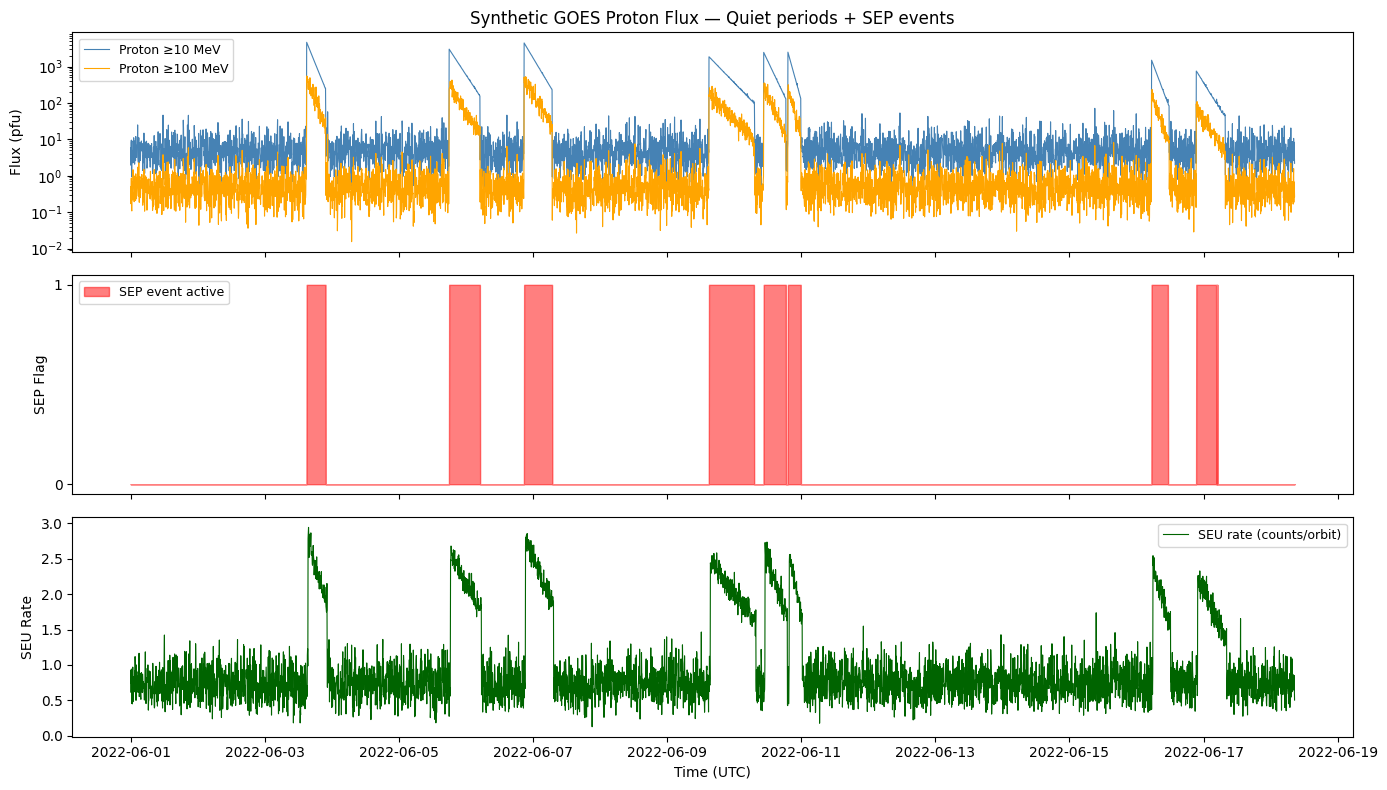

SEP events detected: 11


In [2]:
# ── Plot synthetic time series ─────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].semilogy(df.index, df["flux_p6_gt10mev"], color="steelblue", lw=0.8, label="Proton ≥10 MeV")
axes[0].semilogy(df.index, df["flux_p9_gt100mev"], color="orange",   lw=0.8, label="Proton ≥100 MeV")
axes[0].set_ylabel("Flux (pfu)")
axes[0].set_title("Synthetic GOES Proton Flux — Quiet periods + SEP events")
axes[0].legend(fontsize=9)

axes[1].fill_between(df.index, df["sep_event_active"],
                     color="red", alpha=0.5, label="SEP event active")
axes[1].set_ylabel("SEP Flag")
axes[1].set_yticks([0, 1])
axes[1].legend(fontsize=9)

axes[2].plot(df.index, df["seu_rate"], color="darkgreen", lw=0.8, label="SEU rate (counts/orbit)")
axes[2].set_ylabel("SEU Rate")
axes[2].set_xlabel("Time (UTC)")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()
print(f"SEP events detected: {int(df['sep_event_active'].diff().clip(0).sum())}")


---
## 3. Preprocessing

### 3.1 Log-transform

Particle flux follows a **log-normal distribution** — values span 4–5 orders of magnitude. Training an LSTM directly on raw flux leads to gradient instability. We apply `log1p(x)` which:
- Compresses the dynamic range
- Handles zero values gracefully (log1p(0) = 0)
- Preserves the relative ordering of flux levels

### 3.2 Robust normalisation

We use **RobustScaler** (median / IQR) rather than StandardScaler (mean / std) because:
- SEP event spikes are extreme outliers that inflate the mean and std
- RobustScaler is resistant to these outliers — the median and IQR are unaffected by a handful of very large values
- Reference: Camporeale et al. (2018) recommend robust statistics for space weather data

### 3.3 Sliding window construction

For each timestep *i*, we extract:
- **X[i]** : flux features from timestep *i - window_size* to *i*  → shape `(window_size, n_features)`
- **y[i]** : SEU rate at timestep *i + horizon*                    → scalar

Windows containing any NaN are dropped entirely.


In [3]:
from sklearn.preprocessing import RobustScaler

# ── Parameters ──────────────────────────────────────────────────────────────
WINDOW_SIZE = 24    # 24 × 5-min = 2-hour lookback
HORIZON     = 6     # 6  × 5-min = 30-min forecast

# ── Separate features and labels ────────────────────────────────────────────
feature_cols = [c for c in df.columns if c != "seu_rate"]
label_col    = "seu_rate"

features = df[feature_cols].copy()
labels   = df[label_col].copy()

# ── Log1p transform on flux columns ─────────────────────────────────────────
log_cols = [c for c in feature_cols if "flux" in c]
features[log_cols] = np.log1p(features[log_cols].clip(lower=0))

# ── Train / val / test chronological split BEFORE fitting scaler ─────────────
N      = len(features)
n_test = int(N * 0.15)
n_val  = int(N * 0.15)
n_train = N - n_val - n_test

feat_train = features.iloc[:n_train]
feat_val   = features.iloc[n_train:n_train + n_val]
feat_test  = features.iloc[n_train + n_val:]

# ── Fit scaler on train only (no data leakage) ───────────────────────────────
scaler = RobustScaler()
feat_train_sc = pd.DataFrame(scaler.fit_transform(feat_train),
                              columns=feature_cols, index=feat_train.index)
feat_val_sc   = pd.DataFrame(scaler.transform(feat_val),
                              columns=feature_cols, index=feat_val.index)
feat_test_sc  = pd.DataFrame(scaler.transform(feat_test),
                              columns=feature_cols, index=feat_test.index)

print(f"Split sizes  — train: {n_train}  val: {n_val}  test: {n_test}")
print(f"Train period : {feat_train.index[0].date()} -> {feat_train.index[-1].date()}")
print(f"Val period   : {feat_val.index[0].date()}   -> {feat_val.index[-1].date()}")
print(f"Test period  : {feat_test.index[0].date()}  -> {feat_test.index[-1].date()}")


Split sizes  — train: 3500  val: 750  test: 750
Train period : 2022-06-01 -> 2022-06-13
Val period   : 2022-06-13   -> 2022-06-15
Test period  : 2022-06-15  -> 2022-06-18


In [4]:
# ── Sliding window construction ──────────────────────────────────────────────
def make_windows(feat_df, label_series, window_size, horizon):
    feat_arr  = feat_df.values.astype(np.float32)
    label_arr = label_series.reindex(feat_df.index).values.astype(np.float32)
    X_list, y_list = [], []
    for i in range(window_size, len(feat_arr) - horizon + 1):
        x_win = feat_arr[i - window_size : i]
        y_tgt = label_arr[i + horizon - 1]
        if np.isnan(x_win).any() or np.isnan(y_tgt):
            continue
        X_list.append(x_win)
        y_list.append(y_tgt)
    return np.stack(X_list), np.array(y_list, dtype=np.float32)

X_train, y_train = make_windows(feat_train_sc, labels, WINDOW_SIZE, HORIZON)
X_val,   y_val   = make_windows(feat_val_sc,   labels, WINDOW_SIZE, HORIZON)
X_test,  y_test  = make_windows(feat_test_sc,  labels, WINDOW_SIZE, HORIZON)

print(f"Window shape : (samples, timesteps, features)")
print(f"X_train : {X_train.shape}  y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}    y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}   y_test  : {y_test.shape}")
print(f"\ny_train range : [{y_train.min():.4f}, {y_train.max():.4f}]")


Window shape : (samples, timesteps, features)
X_train : (3471, 24, 5)  y_train : (3471,)
X_val   : (721, 24, 5)    y_val   : (721,)
X_test  : (721, 24, 5)   y_test  : (721,)

y_train range : [0.1259, 2.9444]


---
## 4. PyTorch Dataset & DataLoader

### 4.1 Why not shuffle?

Unlike image classification, **time series data must not be shuffled**. Shuffling would:
- Break the temporal structure the LSTM is designed to learn
- Allow future flux values to appear in training windows evaluated before earlier timesteps
- Cause artificially low training loss and poor generalisation

### 4.2 Batch structure

Each batch has shape `(batch_size, window_size, n_features)` — this is PyTorch's `batch_first=True` convention used in our LSTM.


In [5]:
from torch.utils.data import Dataset, DataLoader

class SEUDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Build datasets and loaders
BATCH_SIZE = 32

train_ds = SEUDataset(X_train, y_train)
val_ds   = SEUDataset(X_val,   y_val)
test_ds  = SEUDataset(X_test,  y_test)

# num_workers=0 for Colab (no multiprocessing needed on CPU)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Inspect one batch
X_batch, y_batch = next(iter(train_dl))
print(f"Batch X shape : {X_batch.shape}  (batch, timesteps, features)")
print(f"Batch y shape : {y_batch.shape}  (batch,)")
print(f"X dtype       : {X_batch.dtype}")
print(f"y range       : [{y_batch.min():.4f}, {y_batch.max():.4f}]")


Batch X shape : torch.Size([32, 24, 5])  (batch, timesteps, features)
Batch y shape : torch.Size([32])  (batch,)
X dtype       : torch.float32
y range       : [0.5036, 1.1644]


---
## 5. LSTM Model Architecture

### 5.1 LSTM cell equations

At each timestep *t*, the LSTM computes:

$$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f) \quad \text{(forget gate)}$$
$$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i) \quad \text{(input gate)}$$
$$\tilde{C}_t = \tanh(W_C [h_{t-1}, x_t] + b_C) \quad \text{(candidate cell state)}$$
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t \quad \text{(cell state update)}$$
$$o_t = \sigma(W_o [h_{t-1}, x_t] + b_o) \quad \text{(output gate)}$$
$$h_t = o_t \odot \tanh(C_t) \quad \text{(hidden state)}$$

### 5.2 Architecture choices (with references)

| Decision | Value | Reference |
|---|---|---|
| Hidden units | 128 | Brownlee (2018) Ch.20: 100–200 for multivariate problems |
| LSTM layers | 2 | Atef et al. (2020): no gain beyond 2 layers |
| Dropout | 0.3 | Brownlee (2018) Ch.25: 0.5 for activity recognition; conservative 0.3 here |
| Loss | Huber (δ=1.0) | Rashid et al. (2026): MSE fails at 5% label corruption; Huber robust to 50% |

### 5.3 Architecture diagram

```
Input (batch, 24, 5)
      │
   LSTM Layer 1 (128 units)
      │  Dropout (0.3)
   LSTM Layer 2 (128 units)
      │  Dropout (0.3)
   Final timestep hidden state (128,)
      │
   Linear(128 → 64) + ReLU
      │
   Linear(64 → 1)
      │
Output: SEU rate scalar
```


In [6]:
import torch.nn as nn

class SEULSTMBaseline(nn.Module):
    def __init__(self, n_features, hidden_size=128, num_layers=2,
                 dropout=0.3, fc_size=64):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(p=dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, fc_size),
            nn.ReLU(),
            nn.Linear(fc_size, 1),
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)        # (B, T, H)
        last_step   = lstm_out[:, -1, :]  # (B, H) — final timestep only
        out         = self.fc(self.dropout(last_step))
        return out.squeeze(1)             # (B,)

N_FEATURES = X_train.shape[2]
device     = "cuda" if torch.cuda.is_available() else "cpu"

model   = SEULSTMBaseline(n_features=N_FEATURES).to(device)
loss_fn = nn.HuberLoss(reduction="mean", delta=1.0)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Device     : {device}")
print(f"N features : {N_FEATURES}")
print(f"Parameters : {n_params:,}")
print(f"\nModel architecture:")
print(model)

# Sanity check forward pass
x_dummy = torch.randn(4, WINDOW_SIZE, N_FEATURES)
y_dummy = model(x_dummy)
print(f"\nForward pass OK — output shape: {y_dummy.shape}")


Device     : cpu
N features : 5
Parameters : 209,537

Model architecture:
SEULSTMBaseline(
  (lstm): LSTM(5, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)

Forward pass OK — output shape: torch.Size([4])


---
## 6. Training

### 6.1 Optimiser: Adam

Adam (Adaptive Moment Estimation) is the standard choice for LSTM training:
- Adapts the learning rate per parameter
- Combines momentum (first moment) and RMSProp (second moment)
- Default lr=1e-3 is well-established for sequence models (Brownlee 2018, Ch.9)

### 6.2 Learning rate schedule: Cosine Annealing

Cosine annealing smoothly decays the learning rate from `lr` to `lr × 0.01` over the training period:

$$\eta_t = \eta_{min} + \frac{1}{2}(\eta_{max} - \eta_{min})\left(1 + \cos\frac{t\pi}{T}\right)$$

This avoids sharp LR drops that can destabilise LSTM training.

### 6.3 Gradient clipping

LSTM gradients can explode during backpropagation through time (BPTT). We clip the global gradient norm to 1.0:
- Prevents weight updates that are disproportionately large
- Standard practice for all RNN-based models (Pascanu et al., 2013)

### 6.4 Early stopping

We stop training when validation loss has not improved for `patience=5` epochs (reduced from 10 for this demo). The best checkpoint is restored for evaluation.


In [7]:
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

EPOCHS    = 20       # small for demo; use 100 on HPC
LR        = 1e-3
PATIENCE  = 5

optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR * 0.01)

history = {"train_loss": [], "val_loss": [], "val_mae": [], "lr": []}
best_val_loss  = float("inf")
best_weights   = None
patience_count = 0

for epoch in range(1, EPOCHS + 1):

    # ── Train ────────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for X_b, y_b in train_dl:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        y_pred = model(X_b)
        loss   = loss_fn(y_pred, y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * len(y_b)
    train_loss /= len(train_ds)

    # ── Validate ─────────────────────────────────────────────────────────────
    model.eval()
    val_loss, val_mae = 0.0, 0.0
    with torch.no_grad():
        for X_b, y_b in val_dl:
            X_b, y_b = X_b.to(device), y_b.to(device)
            y_pred   = model(X_b)
            val_loss += loss_fn(y_pred, y_b).item() * len(y_b)
            val_mae  += (y_pred - y_b).abs().sum().item()
    val_loss /= len(val_ds)
    val_mae  /= len(val_ds)

    scheduler.step()
    lr_now = scheduler.get_last_lr()[0]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_mae"].append(val_mae)
    history["lr"].append(lr_now)

    print(f"Epoch {epoch:3d}/{EPOCHS} | "
          f"train_loss={train_loss:.5f}  val_loss={val_loss:.5f}  "
          f"val_mae={val_mae:.5f}  lr={lr_now:.2e}")

    # ── Early stopping ───────────────────────────────────────────────────────
    if val_loss < best_val_loss - 1e-5:
        best_val_loss = val_loss
        best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} — best val_loss={best_val_loss:.5f}")
            break

# Restore best weights
model.load_state_dict(best_weights)
print("\nBest model restored.")


Epoch   1/20 | train_loss=0.06887  val_loss=0.01855  val_mae=0.15209  lr=9.94e-04
Epoch   2/20 | train_loss=0.02379  val_loss=0.01578  val_mae=0.14312  lr=9.76e-04
Epoch   3/20 | train_loss=0.03813  val_loss=0.00933  val_mae=0.10961  lr=9.46e-04
Epoch   4/20 | train_loss=0.02997  val_loss=0.00990  val_mae=0.11198  lr=9.05e-04
Epoch   5/20 | train_loss=0.01796  val_loss=0.00689  val_mae=0.09427  lr=8.55e-04
Epoch   6/20 | train_loss=0.01993  val_loss=0.00770  val_mae=0.09854  lr=7.96e-04
Epoch   7/20 | train_loss=0.01846  val_loss=0.00742  val_mae=0.09745  lr=7.30e-04
Epoch   8/20 | train_loss=0.01516  val_loss=0.00630  val_mae=0.09048  lr=6.58e-04
Epoch   9/20 | train_loss=0.01353  val_loss=0.00654  val_mae=0.09222  lr=5.82e-04
Epoch  10/20 | train_loss=0.01154  val_loss=0.00601  val_mae=0.08849  lr=5.05e-04
Epoch  11/20 | train_loss=0.01231  val_loss=0.00589  val_mae=0.08810  lr=4.28e-04
Epoch  12/20 | train_loss=0.00821  val_loss=0.00568  val_mae=0.08650  lr=3.52e-04
Epoch  13/20 | t

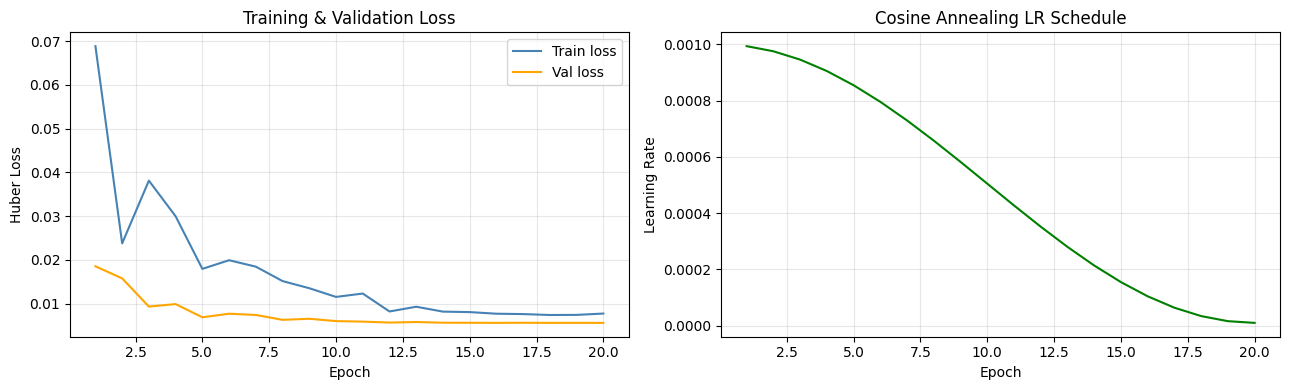

In [8]:
# ── Plot training curves ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

epochs_ran = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_ran, history["train_loss"], label="Train loss", color="steelblue")
axes[0].plot(epochs_ran, history["val_loss"],   label="Val loss",   color="orange")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Huber Loss")
axes[0].set_title("Training & Validation Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history["lr"], color="green")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Learning Rate")
axes[1].set_title("Cosine Annealing LR Schedule")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 7. Evaluation

### 7.1 Metrics

| Metric | Formula | Interpretation |
|---|---|---|
| **MAE** | $\frac{1}{N}\sum|\hat{y}-y|$ | Average absolute error in SEU rate units |
| **RMSE** | $\sqrt{\frac{1}{N}\sum(\hat{y}-y)^2}$ | Penalises large errors more — sensitive to SEP spikes |
| **MAPE** | $\frac{100}{N}\sum\frac{|\hat{y}-y|}{|y|}$ | Percentage error — useful for comparing across datasets |

RMSE > MAE indicates the model struggles with large SEP-driven SEU spikes — expected for a baseline.

### 7.2 What to look for

- **Predicted vs actual plot:** Does the model track the general trend?
- **SEP event windows:** Does the model anticipate or lag the spike?
- **Quiet periods:** Is the baseline prediction stable and accurate?


In [9]:
# ── Test set evaluation ──────────────────────────────────────────────────────
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for X_b, y_b in test_dl:
        X_b    = X_b.to(device)
        y_pred = model(X_b).cpu()
        all_preds.append(y_pred)
        all_targets.append(y_b)

y_pred_all = torch.cat(all_preds).numpy()
y_true_all = torch.cat(all_targets).numpy()

mae  = np.abs(y_pred_all - y_true_all).mean()
rmse = np.sqrt(((y_pred_all - y_true_all) ** 2).mean())
mask = np.abs(y_true_all) > 1e-6
mape = np.abs((y_pred_all[mask] - y_true_all[mask]) / y_true_all[mask]).mean() * 100

print("=" * 40)
print(f"Test MAE  : {mae:.5f}")
print(f"Test RMSE : {rmse:.5f}")
print(f"Test MAPE : {mape:.2f}%")
print("=" * 40)
print(f"\nNote: RMSE > MAE is expected — SEP spike residuals inflate RMSE.")


Test MAE  : 0.08482
Test RMSE : 0.10589
Test MAPE : 10.14%

Note: RMSE > MAE is expected — SEP spike residuals inflate RMSE.


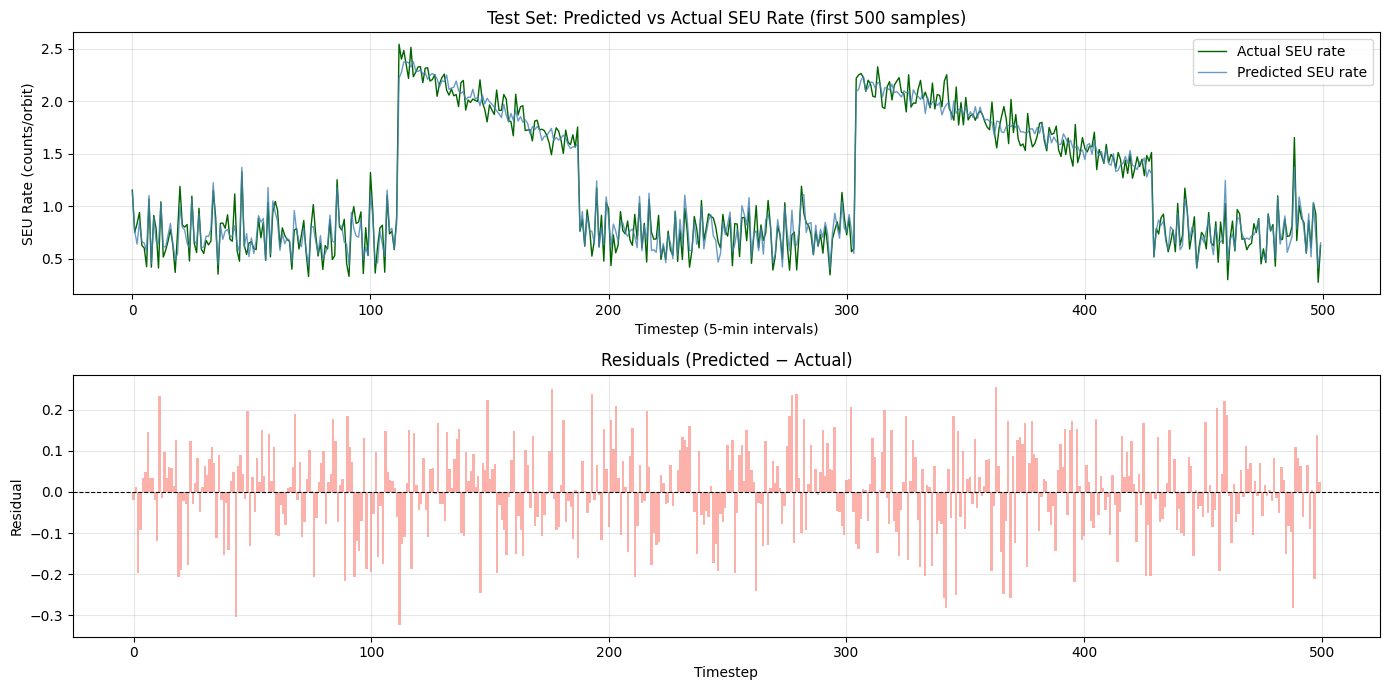

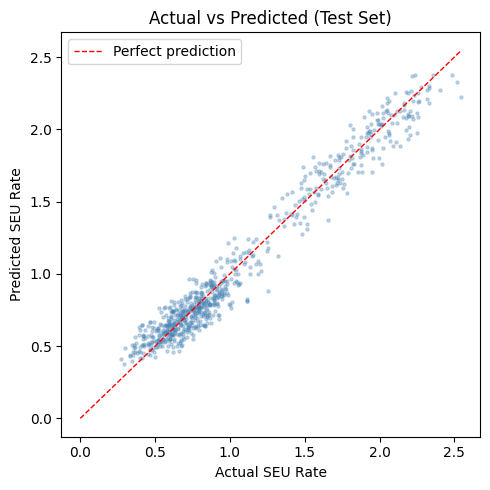

In [10]:
# ── Predicted vs actual plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

n_plot = min(500, len(y_true_all))
x_ax   = np.arange(n_plot)

axes[0].plot(x_ax, y_true_all[:n_plot], label="Actual SEU rate",    color="darkgreen",  lw=1.0)
axes[0].plot(x_ax, y_pred_all[:n_plot], label="Predicted SEU rate", color="steelblue",  lw=1.0, alpha=0.8)
axes[0].set_title("Test Set: Predicted vs Actual SEU Rate (first 500 samples)")
axes[0].set_xlabel("Timestep (5-min intervals)")
axes[0].set_ylabel("SEU Rate (counts/orbit)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_pred_all[:n_plot] - y_true_all[:n_plot]
axes[1].bar(x_ax, residuals, color="salmon", alpha=0.6, width=1.0)
axes[1].axhline(0, color="black", lw=0.8, linestyle="--")
axes[1].set_title("Residuals (Predicted − Actual)")
axes[1].set_xlabel("Timestep")
axes[1].set_ylabel("Residual")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Scatter plot
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_true_all, y_pred_all, alpha=0.3, s=5, color="steelblue")
lim = max(y_true_all.max(), y_pred_all.max())
ax.plot([0, lim], [0, lim], "r--", lw=1, label="Perfect prediction")
ax.set_xlabel("Actual SEU Rate")
ax.set_ylabel("Predicted SEU Rate")
ax.set_title("Actual vs Predicted (Test Set)")
ax.legend()
plt.tight_layout()
plt.show()


---
## 8. Next Steps

### 8.1 Moving to HPC (FT3)

The full pipeline on real data uses the same code — just replace synthetic data with:

```bash
# On FT3 login node:
python data_acquisition.py --start 2020-01-01 --end 2023-12-31 --cache-dir $SCRATCH/data/raw
python preprocess.py --cache-dir $SCRATCH/data/raw --out-dir $SCRATCH/data/processed \
                     --creme96-csv $SCRATCH/creme96_seu_rates.csv
sbatch submit.slurm
```

### 8.2 Hyperparameters to tune (next experiment)

| Parameter | Baseline | Search range |
|---|---|---|
| Hidden units | 128 | 64, 128, 256 |
| LSTM layers | 2 | 1, 2, 3 |
| Dropout | 0.3 | 0.1, 0.2, 0.3, 0.5 |
| Window size | 24 (2h) | 12, 24, 48, 96 |
| Horizon | 6 (30min) | 6, 12, 24 |
| Huber delta | 1.0 | 0.5, 1.0, 2.0 |

### 8.3 Planned model improvements

1. **Bidirectional LSTM** — Nedal et al. (2023) show BiLSTM outperforms unidirectional for proton flux forecasting
2. **Attention mechanism** — weight timesteps by relevance to the prediction horizon
3. **Multi-task learning** — jointly predict SEU rate + SEP event onset (Yu et al., 2026)
4. **Ensemble** — train multiple LSTM seeds, report mean ± std for uncertainty quantification

### 8.4 Parallelisation roadmap

| Component | Current | Planned |
|---|---|---|
| Data fetch | Sequential (monthly loop) | `multiprocessing.Pool` |
| Preprocessing | Single-threaded | Vectorised numpy |
| Training | Single GPU | `DistributedDataParallel` (multi-GPU) |

---

*References: Brownlee (2018), Camporeale et al. (2018), Nedal et al. (2023), Atef et al. (2020), Rashid et al. (2026), Yu et al. (2026)*
